LSTM Model - Long Short Term Memory (type of recurrent neural network)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from statsmodels.tsa.arima_model import ARIMA

In [3]:
nike_data = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/Nike_historical_data.csv')

In [4]:
nike_data.head(n= 10)

,Date,Open,High,Low,Close,Volume,ticker,name
0,1980-12-02 00:00:00-05:00,0.123572,0.126258,0.123572,0.123572,100710400,NKE,"Nike, Inc. (NKE) Historical Data"
1,1980-12-03 00:00:00-05:00,0.122228,0.122228,0.120885,0.120885,25177600,NKE,"Nike, Inc. (NKE) Historical Data"
2,1980-12-04 00:00:00-05:00,0.124915,0.126258,0.124915,0.124915,22694400,NKE,"Nike, Inc. (NKE) Historical Data"
3,1980-12-05 00:00:00-05:00,0.120885,0.120885,0.118199,0.118199,7590400,NKE,"Nike, Inc. (NKE) Historical Data"
4,1980-12-08 00:00:00-05:00,0.112826,0.112826,0.111483,0.111483,5414400,NKE,"Nike, Inc. (NKE) Historical Data"
5,1980-12-09 00:00:00-05:00,0.111483,0.111483,0.108796,0.108796,5824000,NKE,"Nike, Inc. (NKE) Historical Data"
6,1980-12-10 00:00:00-05:00,0.106110,0.106110,0.102081,0.102081,5875200,NKE,"Nike, Inc. (NKE) Historical Data"
7,1980-12-11 00:00:00-05:00,0.099394,0.099394,0.096708,0.096708,5440000,NKE,"Nike, Inc. (NKE) Historical Data"
8,1980-12-12 00:00:00-05:00,0.100737,0.102081,0.100737,0.100737,8153600,NKE,"Nike, Inc. (NKE) Historical Data"
9,1980-12-15 00:00:00-05:00,0.104767,0.106110,0.104767,0.104767,6643200,NKE,"Nike, Inc. (NKE) Historical Data"


In [5]:
from datetime import datetime

In [7]:
nike_data['Date'] = pd.to_datetime(nike_data['Date'])

/var/folders/bt/k7t4mr2j6kq79jv3vbj756z80000gn/T/ipykernel_17930/912388666.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  nike_data['Date'] = pd.to_datetime(nike_data['Date'])


In [10]:
nike_data['Date'] = pd.to_datetime(nike_data['Date'], utc=True)

In [11]:
nike_data['Date'] = pd.to_datetime(nike_data['Date']).dt.tz_localize(None)

In [12]:
nike_data.head(10)

,Date,Open,High,Low,Close,Volume,ticker,name
0,1980-12-02 05:00:00,0.123572,0.126258,0.123572,0.123572,100710400,NKE,"Nike, Inc. (NKE) Historical Data"
1,1980-12-03 05:00:00,0.122228,0.122228,0.120885,0.120885,25177600,NKE,"Nike, Inc. (NKE) Historical Data"
2,1980-12-04 05:00:00,0.124915,0.126258,0.124915,0.124915,22694400,NKE,"Nike, Inc. (NKE) Historical Data"
3,1980-12-05 05:00:00,0.120885,0.120885,0.118199,0.118199,7590400,NKE,"Nike, Inc. (NKE) Historical Data"
4,1980-12-08 05:00:00,0.112826,0.112826,0.111483,0.111483,5414400,NKE,"Nike, Inc. (NKE) Historical Data"
5,1980-12-09 05:00:00,0.111483,0.111483,0.108796,0.108796,5824000,NKE,"Nike, Inc. (NKE) Historical Data"
6,1980-12-10 05:00:00,0.106110,0.106110,0.102081,0.102081,5875200,NKE,"Nike, Inc. (NKE) Historical Data"
7,1980-12-11 05:00:00,0.099394,0.099394,0.096708,0.096708,5440000,NKE,"Nike, Inc. (NKE) Historical Data"
8,1980-12-12 05:00:00,0.100737,0.102081,0.100737,0.100737,8153600,NKE,"Nike, Inc. (NKE) Historical Data"
9,1980-12-15 05:00:00,0.104767,0.106110,0.104767,0.104767,6643200,NKE,"Nike, Inc. (NKE) Historical Data"


Data Preprocessing

In [15]:
nike_data.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
ticker    0
name      0
dtype: int64

In [16]:
nike_data.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
ticker    0
name      0
dtype: int64

Feature Engineering : We extract useful features like moving averages and daily returns

In [17]:
nike_data['7-Day MA'] = nike_data['Close'].rolling(window=7).mean()

In [18]:
nike_data['50-Day MA'] = nike_data['Close'].rolling(window=50).mean()

In [19]:
nike_data['Daily Return'] = nike_data['Close'].pct_change()

    Scaling the data :LSTMs perform better with normalized data. We use MinMax Scaling to scale prices between 0 and 1:

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(nike_data['Close'].values.reshape(-1,1))

Checking for stationary

In [22]:
from statsmodels.tsa.stattools import adfuller

In [23]:
close_series = nike_data['Close'].dropna()

In [24]:
### Run ADF test
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("The time series is stationary.")
    else:
        print("The time series is non-stationary.")


In [25]:
check_stationarity(close_series)

ADF Statistic: -0.957955
p-value: 0.768289
The time series is non-stationary.


In [26]:
from sklearn.model_selection import train_test_split

def create_dataset(data, time_step=1):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        a = data[i:(i+time_step), 0]
        X.append(a)
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

In [27]:
X, Y = create_dataset(scaled_data, time_step=100)
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=42)

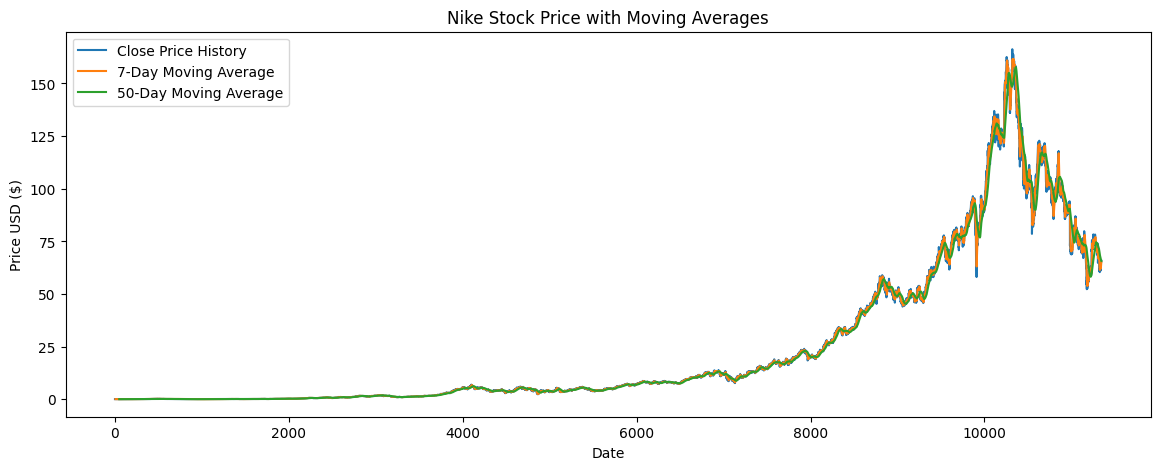

In [28]:
plt.figure(figsize=(14,5))
plt.plot(nike_data['Close'], label='Close Price History')
plt.plot(nike_data['7-Day MA'], label='7-Day Moving Average')
plt.plot(nike_data['50-Day MA'], label='50-Day Moving Average')
plt.title('Nike Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price USD ($)')
plt.legend()
plt.show()

    The stock price exhibits an upward trend with fluctuations.
    There are periods of high volatility, suggesting possible external market influences.

Understanding box plots 

In [29]:
import math
import matplotlib.pyplot as plt
import seaborn as sns  

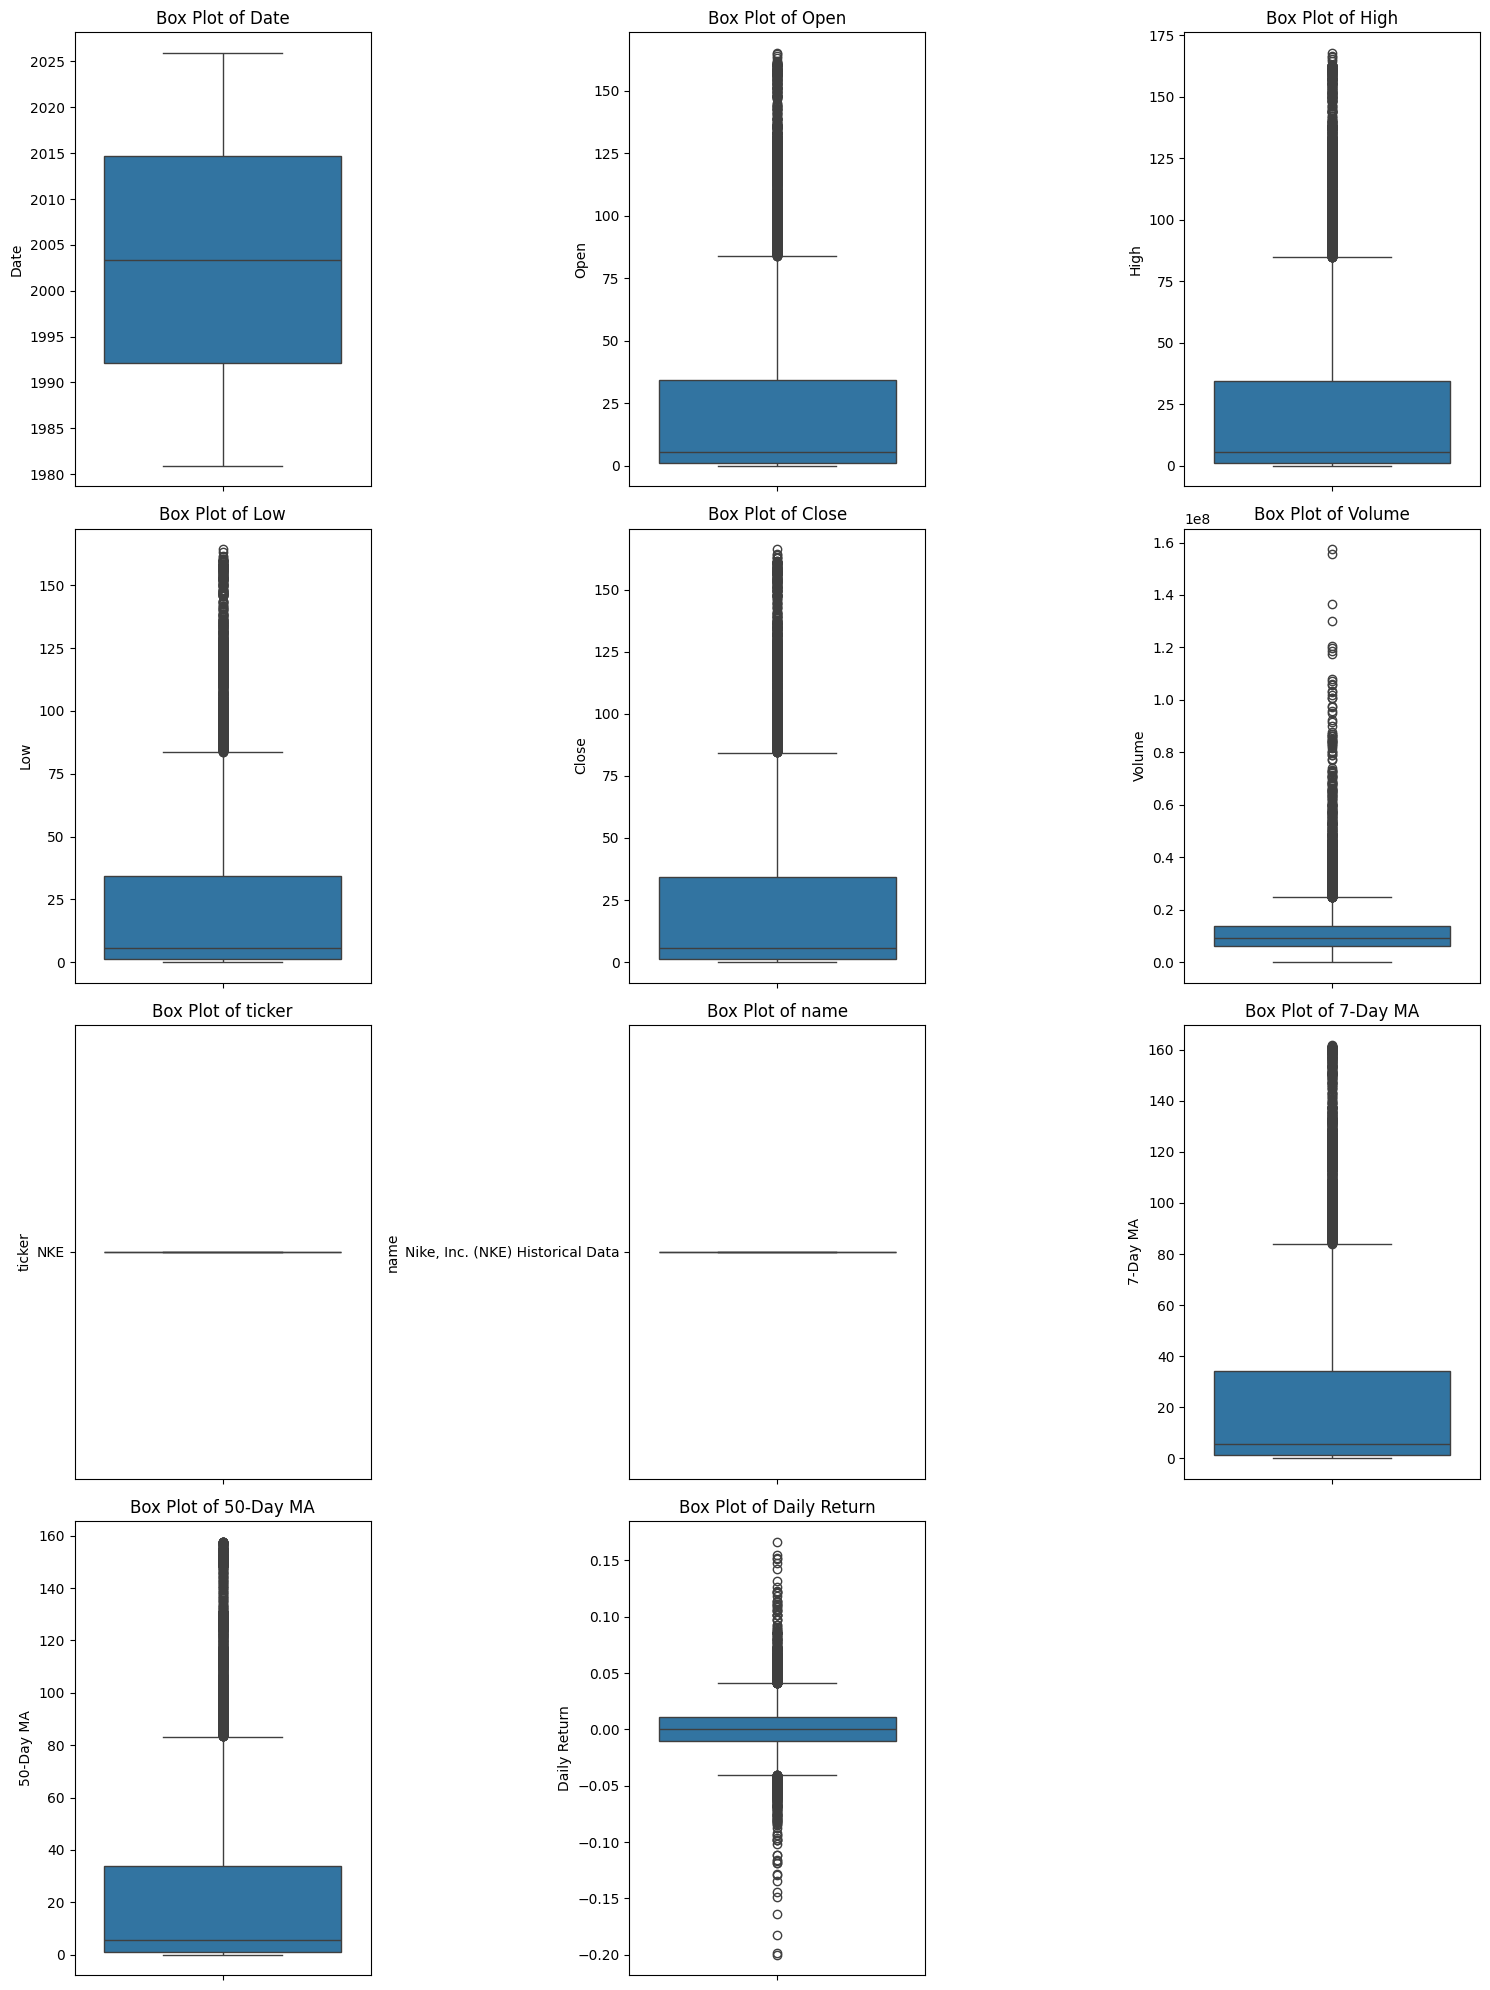

In [31]:
num_columns = 3
num_features = len(nike_data.columns)
num_rows = math.ceil(num_features / num_columns)

fig = plt.figure(figsize=(15, num_rows * 5))
for i, column in enumerate(nike_data.columns):
    ax = fig.add_subplot(num_rows, num_columns, i + 1)
    sns.boxplot(y=nike_data[column], ax=ax)
    ax.set_title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

    Box plots help us identify outliers, especially in features like volume and closing price.
    Features like daily returns may show high variance, indicating periods of increased volatility.
    If any box plot has extreme outliers, it may suggest anomalous trading days or incorrect data points.

Preparing Data for LSTM

In [32]:
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

Build the LSTM Architecture

In [35]:
import tensorflow as tf

ModuleNotFoundError: No module named 'tensorflow'

In [33]:
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

ModuleNotFoundError: No module named 'tensorflow'